### Chapter 3 - Stationary Time Series Models

#### 3.1.2 Differencing and Stationarity

Computing differences between consecutive time series values - we can make it stationary. Method of making a nonstationary time series stationary is called differencing. Can help stabilise the mean and variance of a time series, and therefore removing (or reducing) trend and seasonality.

* do differencing to make a nonstationary time series stationary
* if a time series possesses trend but no seasonality, in order to make it stationary, just use dth order differencing
* it a time series has seasonality, should firstly do seasonal differencing, then consider whether the dth order differencing is needed
    * **seasonal differencing** is subtracting the value from the same point in a previous season/cycle

#### Moving Average Models

MA(q) model - just the equation itself, a mathematical recipe. MA(q) process - an actual time series {X_t}, that is stationary and satisfies the equation.

$$X_t = \mu + \varepsilon_t + \theta_1\varepsilon_{t-1} + \theta_2\varepsilon_{t-2} + \cdots + \theta_q\varepsilon_{t-q}$$

When building a MA model, ACF of MA(q) cuts off after lag q. i.e for all k > q, p_k = 0.

For a given ACF, there exists only one unique invertible MA process, whose autocorrelation function corresponds to the one given

#### Autoregressive Models

AR(p) is defined as follows

$$X_t = \mu + \phi_1 X_{t-1} + \phi_2 X_{t-2} + \cdots + \phi_p X_{t-p} + \varepsilon_t$$

* model can be non - stationary. Is stationary only when roots lie strictly outside the unit circle
* PACF cuts off after lag p

**Stationarity and Causality of AR models**

<Axes: >

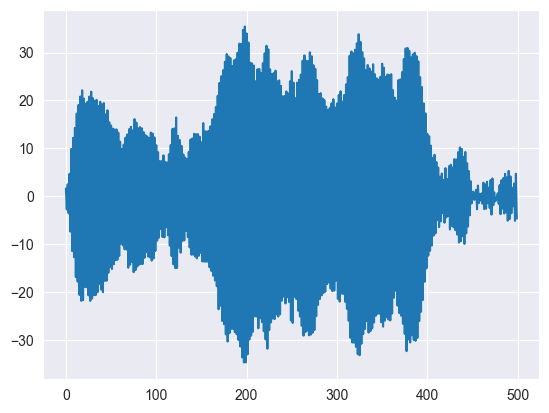

In [13]:
import pandas as pd
from statsmodels.tsa.arima_process import arma_generate_sample
import numpy as np

ar = np.array([1, 1.3, 0.3])
np.random.seed(1)

x = arma_generate_sample(ar=ar, ma=[1], nsample=500)
x=pd.Series(x)

import matplotlib.pyplot as plt
x.plot()

#### ARMA Model

ARMA(p, q) process is defined as follows:

$$X_t = \phi_0 + \phi_1 X_{t-1} + \cdots + \phi_p X_{t-p} + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \cdots + \theta_q \varepsilon_{t-q}$$


Properties of ARMA models:
1. ARMA(p, q) stationary iff AR part is stationary
2. ARMA(p, q) invertible iff MA part invertible
3. ARMA(p, q) causal iff AR part causal

For an ARMA(p, q) model, instead of ACF, PACF cutting off after p/q, both tail off instead

Key takeaways from the chapter:

* backshift operator can be used to make a non stationary time series appear stationary
* for seasonality correlated time series, make sure to subtract effect of a seasonality correlation
* AR model uses historic white noise to generate current value - current value weighted sum of the previous p values of the series itself, plus a new shock. "auto" means its regressed on itself. Can be nonstationary if weights are too large, and the series explodes
* MA model - current value is a weighted sum of current and previous q random shocks, plus a mean. It has no memory os past X_t values, only past surprises -> always stationary
* ARMA model combines both - gives much more flexibility in capturing real world tie series behaviour without needing very large p or q individually